In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
import pandas as pd
import base64
from IPython.display import display, HTML
import ipynbname
from pathlib import Path
from pyvis.network import Network
import json
import random

def create_pyvis_graph(G, filename, directed=False):
    try:
        filename = str(Path(ipynbname.path().parent)) + "\\" + filename
    except:
        pass

    
    net = Network(height="600px", width="100%", directed=True, notebook=False, cdn_resources='in_line')
    
    net.from_nx(G.copy())

    processed_pairs = {} 

    for edge in net.edges:
        src = edge['from']
        dst = edge['to']
        
        pair = tuple(sorted((str(src), str(dst))))
        
        count = processed_pairs.get(pair, 0)
        
        if count == 0:
            roundness = 0
        else:
            step = 0.3
            multiplier = (count + 1) // 2
            sign = 1 if count % 2 != 0 else -1
            roundness = sign * multiplier * step

        edge['smooth'] = {
            'enabled': True,
            'type': 'curvedCW',
            'roundness': roundness
        }
        
        if not directed:
            edge['arrows'] = {'to': {'enabled': False}}
        
        processed_pairs[pair] = count + 1

    options = {
        "edges": {
            "color": {
                "color": "#2B7CE9",
                "highlight": "#FF0000",
                "hover": "#FFF200"    
            },
            "selectionWidth": 3,
            "smooth": {
                "enabled": True, 
                "type": "curvedCW", 
                "roundness": 0.2
            }
        },
        "physics": {
            "enabled": True,
            "solver": "barnesHut",
            "barnesHut": {
                "gravitationalConstant": -3000,
                "centralGravity": 0.3,
                "springLength": 200,
                "springConstant": 0.04,
                "damping": 0.09,
                "avoidOverlap": 0.1
            }
        },
        "interaction": {
            "hover": True,
            "navigationButtons": True
        }
    }

    net.set_options(json.dumps(options))
    
    try:
        html_content = net.generate_html()
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"Готово: {filename}")
    except Exception as e:
        print(f"Ошибка: {e}")
        
    return filename



def show_html_file(filename):
    try:
        with open(filename, "rb") as f:
            html_content = f.read()
            
        b64_content = base64.b64encode(html_content).decode('utf-8')
        data_url = f'data:text/html;charset=utf-8;base64,{b64_content}'
        iframe = f'<iframe src="{data_url}" width="100%" height="650px" style="border: 1px solid #ddd; border-radius: 5px;"></iframe>'
        
        display(HTML(iframe))
        
    except FileNotFoundError:
        print(f"Файл {filename} не найден. Проверьте путь.")
        



# Задания

## 1)



### G1

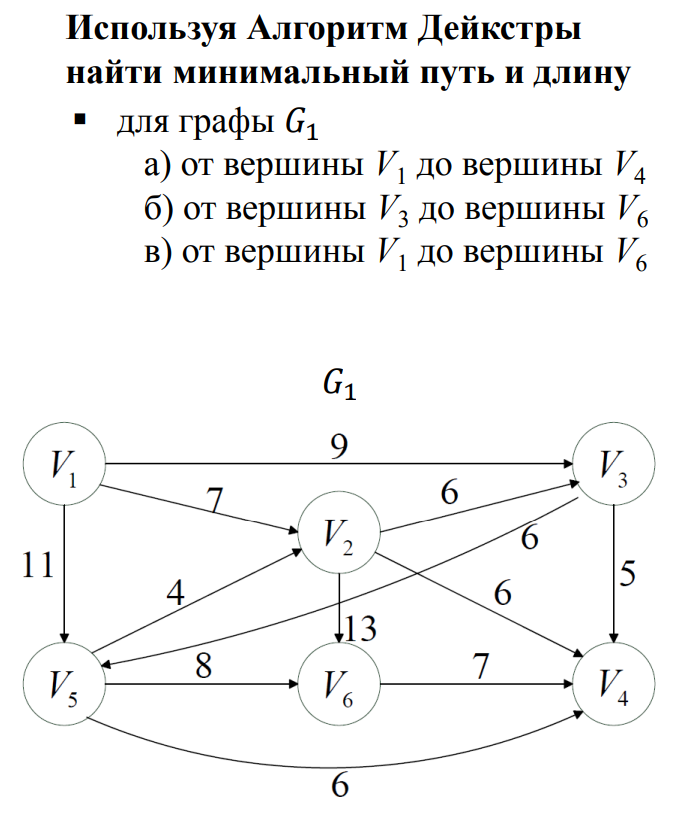

In [3]:
G1 = nx.DiGraph()

# V1 -> ...
G1.add_edge('V1', 'V2', weight=7)
G1.add_edge('V1', 'V3', weight=9)
G1.add_edge('V1', 'V5', weight=11)

# V2 -> ...
G1.add_edge('V2', 'V3', weight=6)
G1.add_edge('V2', 'V4', weight=6)
G1.add_edge('V2', 'V6', weight=13)

# V3 -> ...
G1.add_edge('V3', 'V5', weight=6)
G1.add_edge('V3', 'V4', weight=5)

# V5 -> ...
G1.add_edge('V5', 'V2', weight=4)
G1.add_edge('V5', 'V6', weight=8)
G1.add_edge('V5', 'V4', weight=6)

# V6 -> ...
G1.add_edge('V6', 'V4', weight=7)

show_html_file(create_pyvis_graph(G1,r"renders/4_1_G1.html", True))

Готово: c:\Projects\FU\Course_3\GRAPHS\renders/4_1_G1.html


c:\Projects\FU\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [4]:



# Функция для вывода результатов поиска пути
def print_shortest_path(graph, source, target):
    try:
        path = nx.dijkstra_path(graph, source, target)
        length = nx.dijkstra_path_length(graph, source, target)
        print(f"Путь от {source} до {target}: {path}, Длина: {length}")
    except nx.NetworkXNoPath:
        print(f"Путь от {source} до {target} не найден.")


# а) от вершины V1 до вершины V4
print("а)")
print_shortest_path(G1, 'V1', 'V4')

# б) от вершины V3 до вершины V6
print("\nб)")
print_shortest_path(G1, 'V3', 'V6')

# в) от вершины V1 до вершины V6
print("\nв)")
print_shortest_path(G1, 'V1', 'V6')

а)
Путь от V1 до V4: ['V1', 'V2', 'V4'], Длина: 13

б)
Путь от V3 до V6: ['V3', 'V5', 'V6'], Длина: 14

в)
Путь от V1 до V6: ['V1', 'V5', 'V6'], Длина: 19


### G2

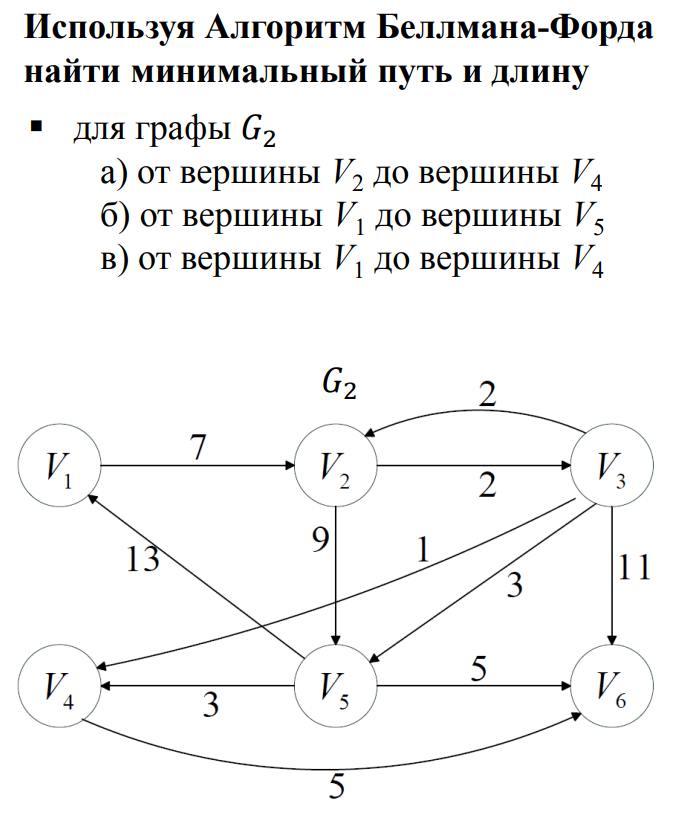

In [5]:
G2 = nx.DiGraph()

# От V1
G2.add_edge('V1', 'V2', weight=7)

# От V2
G2.add_edge('V2', 'V3', weight=2)
G2.add_edge('V2', 'V5', weight=9)

# От V3
G2.add_edge('V3', 'V2', weight=2)  # Верхняя изогнутая стрелка
G2.add_edge('V3', 'V4', weight=1)
G2.add_edge('V3', 'V5', weight=3)
G2.add_edge('V3', 'V6', weight=11)

# От V4
G2.add_edge('V4', 'V6', weight=5)

# От V5
G2.add_edge('V5', 'V1', weight=13)
G2.add_edge('V5', 'V4', weight=3)
G2.add_edge('V5', 'V6', weight=5)

show_html_file(create_pyvis_graph(G2,r"renders/4_1_G2.html", True))

Готово: c:\Projects\FU\Course_3\GRAPHS\renders/4_1_G2.html


c:\Projects\FU\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [6]:
# Функция для вывода пути с использованием алгоритма Беллмана-Форда
def print_bellman_ford_path(graph, source, target):
    try:
        # NetworkX имеет встроенную реализацию Bellman-Ford
        path = nx.bellman_ford_path(graph, source, target, weight='weight')
        length = nx.bellman_ford_path_length(graph, source, target, weight='weight')
        print(f"Путь от {source} до {target}: {path}, Длина: {length}")
    except nx.NetworkXNoPath:
        print(f"Путь от {source} до {target} не найден.")
    except nx.NodeNotFound as e:
        print(f"Ошибка: {e}")

# а) от вершины V2 до вершины V4
print("а)")
print_bellman_ford_path(G2, 'V2', 'V4')

# б) от вершины V1 до вершины V5
print("\nб)")
print_bellman_ford_path(G2, 'V1', 'V5')

# в) от вершины V1 до вершины V4
print("\nв)")
print_bellman_ford_path(G2, 'V1', 'V4')

а)
Путь от V2 до V4: ['V2', 'V3', 'V4'], Длина: 3

б)
Путь от V1 до V5: ['V1', 'V2', 'V3', 'V5'], Длина: 12

в)
Путь от V1 до V4: ['V1', 'V2', 'V3', 'V4'], Длина: 10


# Задания для самостоятельной работы

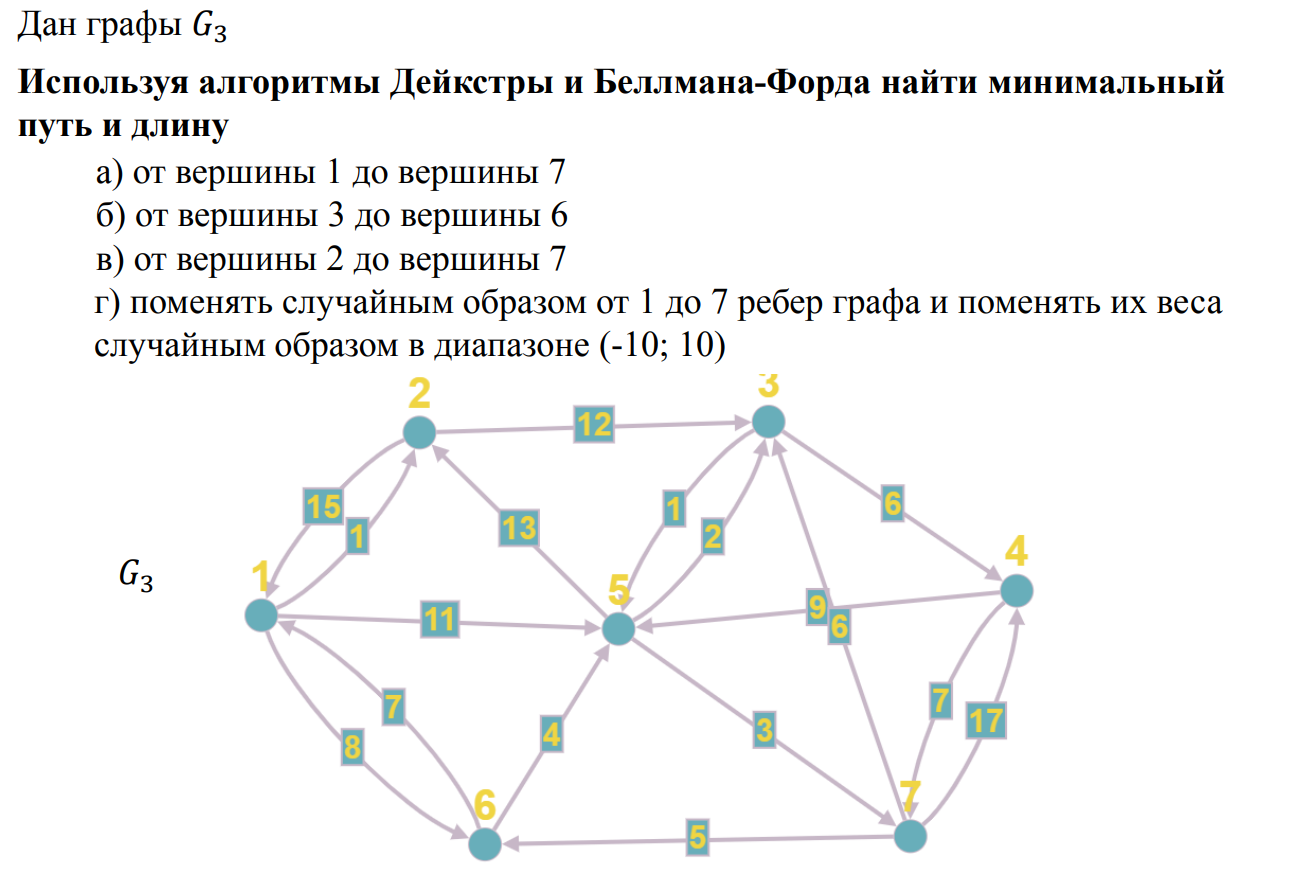

In [7]:
G3 = nx.DiGraph()

# Добавление ребер с весами согласно схеме
# Формат: (откуда, куда, вес)
edges = [
    (1, 2, 15), (2, 1, 1),
    (1, 5, 11), (1, 6, 8), (6, 1, 7),
    (2, 3, 12), (2, 5, 13),
    (3, 5, 2), (5, 3, 1),
    (3, 4, 6),
    (5, 4, 9), (4, 5, 6),
    (6, 5, 4),
    (5, 7, 3), (7, 6, 5),
    (4, 7, 7), (7, 4, 17)
]

G3.add_weighted_edges_from(edges)
show_html_file(create_pyvis_graph(G3,r"renders/4_1_G3.html", True))

Готово: c:\Projects\FU\Course_3\GRAPHS\renders/4_1_G3.html


c:\Projects\FU\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [8]:
# Функция для поиска пути двумя алгоритмами
def find_and_print_path(graph, source, target, task_name):
    print(f"\n--- {task_name} (от {source} до {target}) ---")
    
    # Алгоритм Дейкстры (работает только с неотрицательными весами)
    try:
        d_path = nx.dijkstra_path(graph, source, target)
        d_len = nx.dijkstra_path_length(graph, source, target)
        print(f"[Дейкстра] Путь: {d_path}, Длина: {d_len}")
    except nx.NetworkXNoPath:
        print(f"[Дейкстра] Путь не найден.")
    except nx.NodeNotFound:
        print(f"[Дейкстра] Ошибка: узел не найден.")
    except ValueError as e:
        print(f"[Дейкстра] Невозможно применить (отрицательные веса): {e}")

    # Алгоритм Беллмана-Форда (работает с отрицательными весами, если нет отрицательных циклов)
    try:
        bf_path = nx.bellman_ford_path(graph, source, target)
        bf_len = nx.bellman_ford_path_length(graph, source, target)
        print(f"[Беллман-Форд] Путь: {bf_path}, Длина: {bf_len}")
    except nx.NetworkXUnbounded:
        print(f"[Беллман-Форд] Обнаружен отрицательный цикл!")
    except nx.NetworkXNoPath:
        print(f"[Беллман-Форд] Путь не найден.")


In [ ]:
# Выполнение пунктов а, б, в
print("ИСХОДНЫЙ ГРАФ:")
find_and_print_path(G3, 1, 7, "Пункт а)")
find_and_print_path(G3, 3, 6, "Пункт б)")
find_and_print_path(G3, 2, 7, "Пункт в)")


ИСХОДНЫЙ ГРАФ:

--- Пункт а) (от 1 до 7) ---
[Дейкстра] Путь: [1, 5, 7], Длина: 14
[Беллман-Форд] Путь: [1, 5, 7], Длина: 14

--- Пункт б) (от 3 до 6) ---
[Дейкстра] Путь: [3, 5, 7, 6], Длина: 10
[Беллман-Форд] Путь: [3, 5, 7, 6], Длина: 10

--- Пункт в) (от 2 до 7) ---
[Дейкстра] Путь: [2, 1, 5, 7], Длина: 15
[Беллман-Форд] Путь: [2, 1, 5, 7], Длина: 15


In [10]:
# Пункт г: Изменение случайных ребер
print("\n" + "="*40)
print("Пункт г) МОДИФИКАЦИЯ ГРАФА")
print("="*40)

# Выбираем от 1 до 7 случайных ребер
k = random.randint(1, 7)
edges_list = list(G3.edges(data=True))
selected_edges = random.sample(edges_list, k)

print(f"Выбрано ребер для изменения: {k}")

for u, v, data in selected_edges:
    old_weight = data['weight']
    new_weight = random.randint(-10, 10)
    G3[u][v]['weight'] = new_weight
    print(f"Ребро {u}->{v}: вес изменен с {old_weight} на {new_weight}")

# Проверка путей после изменений (используем Беллмана-Форда, так как появились отрицательные веса)
print("\nПроверка путей после модификации (только Беллман-Форд):")
# Для примера проверим путь из а)
try:
    path = nx.bellman_ford_path(G3, 1, 7)
    length = nx.bellman_ford_path_length(G3, 1, 7)
    print(f"Новый путь 1 -> 7: {path}, Длина: {length}")
except nx.NetworkXUnbounded:
    print("В графе появился отрицательный цикл! Бесконечно малый путь.")
except Exception as e:
    print(f"Ошибка поиска пути: {e}")


Пункт г) МОДИФИКАЦИЯ ГРАФА
Выбрано ребер для изменения: 4
Ребро 7->6: вес изменен с 5 на 5
Ребро 6->5: вес изменен с 4 на 7
Ребро 5->4: вес изменен с 9 на -9
Ребро 4->5: вес изменен с 6 на -9

Проверка путей после модификации (только Беллман-Форд):
В графе появился отрицательный цикл! Бесконечно малый путь.
